In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv("car_price_dataset.csv")


In [4]:
df.head()


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [5]:
df.shape

(30, 9)

In [6]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       30 non-null     str    
 1   Year           30 non-null     int64  
 2   Selling_Price  30 non-null     float64
 3   Present_Price  30 non-null     float64
 4   Kms_Driven     30 non-null     int64  
 5   Fuel_Type      30 non-null     str    
 6   Seller_Type    30 non-null     str    
 7   Transmission   30 non-null     str    
 8   Owner          30 non-null     int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 2.2 KB


In [8]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,30.000000,30.000000,30.000000,30.000000,30.0
mean,2015.300000,6.375000,9.643333,27122.266667,0.0
std,1.725069,4.430415,6.202670,14791.347962,0.0
min,2011.000000,2.500000,2.990000,2071.000000,0.0
25%,2014.250000,3.612500,5.800000,16250.000000,0.0
50%,2015.000000,5.325000,8.135000,28500.000000,0.0
75%,2016.750000,7.125000,10.260000,37250.000000,0.0
max,2018.000000,23.000000,30.610000,64532.000000,0.0


In [9]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df["Fuel_Type"].value_counts()

Fuel_Type
Petrol    17
Diesel    13
Name: count, dtype: int64

In [12]:
df["Seller_Type"].value_counts()

Seller_Type
Dealer        24
Individual     6
Name: count, dtype: int64

In [13]:
df["Transmission"].value_counts()

Transmission
Manual       29
Automatic     1
Name: count, dtype: int64

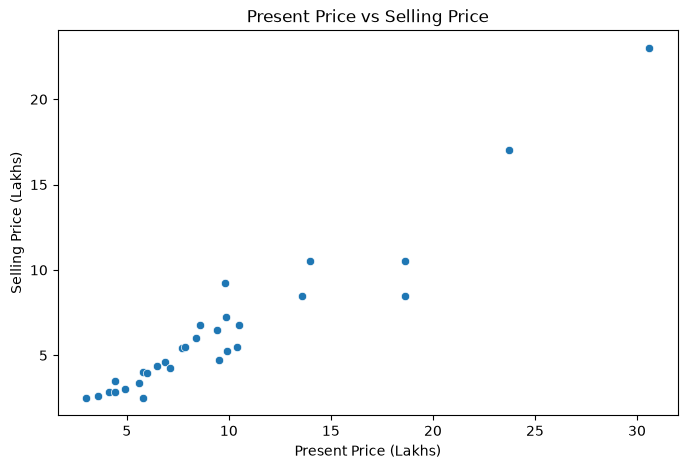

In [14]:
plt.figure(figsize=(8,5))

sns.scatterplot(x="Present_Price", y="Selling_Price", data=df)

plt.xlabel("Present Price (Lakhs)")
plt.ylabel("Selling Price (Lakhs)")
plt.title("Present Price vs Selling Price")

plt.show()

In [15]:
df[["Year", "Selling_Price", "Present_Price", "Kms_Driven"]].corr()

,Year,Selling_Price,Present_Price,Kms_Driven
Year,1.000000,0.106366,-0.004898,-0.213528
Selling_Price,0.106366,1.000000,0.957981,0.164867
Present_Price,-0.004898,0.957981,1.000000,0.238195
Kms_Driven,-0.213528,0.164867,0.238195,1.000000


In [17]:
X = df.drop(["Selling_Price", "Car_Name"], axis=1)
y = df["Selling_Price"]

In [18]:
X.head()

,Year,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,2014,5.59,27000,Petrol,Dealer,Manual,0
1,2013,9.54,43000,Diesel,Dealer,Manual,0
2,2017,9.85,6900,Petrol,Dealer,Manual,0
3,2011,4.15,5200,Petrol,Dealer,Manual,0
4,2014,6.87,42450,Diesel,Dealer,Manual,0


In [19]:
X = pd.get_dummies(X, columns=["Fuel_Type", "Seller_Type", "Transmission"], drop_first=True)

In [20]:
X.head()

,Year,Present_Price,Kms_Driven,Owner,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,2014,5.59,27000,0,True,False,True
1,2013,9.54,43000,0,False,False,True
2,2017,9.85,6900,0,True,False,True
3,2011,4.15,5200,0,True,False,True
4,2014,6.87,42450,0,False,False,True


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [22]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (24, 7)
Testing data: (6, 7)


In [23]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [24]:
y_pred = model.predict(X_test)

In [25]:
print(y_pred)

[6.178    8.8625   8.265    5.2435   3.020075 4.373   ]


In [26]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

comparison

,Actual Price,Predicted Price
0,6.75,6.178000
1,10.50,8.862500
2,10.50,8.265000
3,6.50,5.243500
4,3.00,3.020075
5,4.40,4.373000


In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 0.9580124999999996
RMSE: 1.2638393559326144
R² Score: 0.7984580520175248


In [28]:
new_car = pd.DataFrame({
    "Year": [2017],
    "Present_Price": [10],
    "Kms_Driven": [20000],
    "Owner": [0],
    "Fuel_Type_Petrol": [True],
    "Seller_Type_Individual": [False],
    "Transmission_Manual": [True]
})

predicted_price = model.predict(new_car)

print("Predicted Selling Price:", predicted_price[0], "lakhs")

Predicted Selling Price: 6.825 lakhs


In [29]:
import joblib

joblib.dump(model, "car_price_model.pkl")

print("Model saved successfully!")

Model saved successfully!
